In [1]:
# ==============================================================================
# Student Name: Aditya Pasarkar
# Program: AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares
# Project Title: Telecom Customer Segmentation & Service Tier Analysis
# Dataset Path: D:\ADITYA\teleCust1000t.csv
# ==============================================================================

# Cell 1: Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset directly from your path
file_path = r"D:\ADITYA\teleCust1000t.csv"
df = pd.read_csv(file_path)

# Map category numbers to clear readable names
cat_mapping = {
    1: "Basic Service",
    2: "E-Service",
    3: "Plus Service",
    4: "Total Service"
}
df['category_name'] = df['custcat'].map(cat_mapping)

print("Data Loaded Successfully for Aditya Pasarkar's Internship Project!")
print("Dataset Shape:", df.shape)
df.head()

Data Loaded Successfully for Aditya Pasarkar's Internship Project!
Dataset Shape: (1000, 13)


,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat,category_name
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1,Basic Service
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4,Total Service
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3,Plus Service
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1,Basic Service
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3,Plus Service


In [2]:
# Cell 2: Executive KPIs & Summary Statistics
total_customers = len(df)
avg_income = df['income'].mean()
avg_tenure = df['tenure'].mean()
total_service_pct = (df['custcat'] == 4).mean() * 100

print("="*50)
print("       EXECUTIVE KPIs & OVERVIEW - ADITYA PASARKAR       ")
print("="*50)
print(f"Total Customer Accounts:      {total_customers:,}")
print(f"Average Customer Income:      ${avg_income:.2f}k")
print(f"Average Customer Tenure:      {avg_tenure:.1f} months")
print(f"High-Value (Total Service) %: {total_service_pct:.2f}%")
print("="*50)

df['category_name'].value_counts()

       EXECUTIVE KPIs & OVERVIEW - ADITYA PASARKAR       
Total Customer Accounts:      1,000
Average Customer Income:      $77.53k
Average Customer Tenure:      35.5 months
High-Value (Total Service) %: 23.60%


category_name
Plus Service     281
Basic Service    266
Total Service    236
E-Service        217
Name: count, dtype: int64

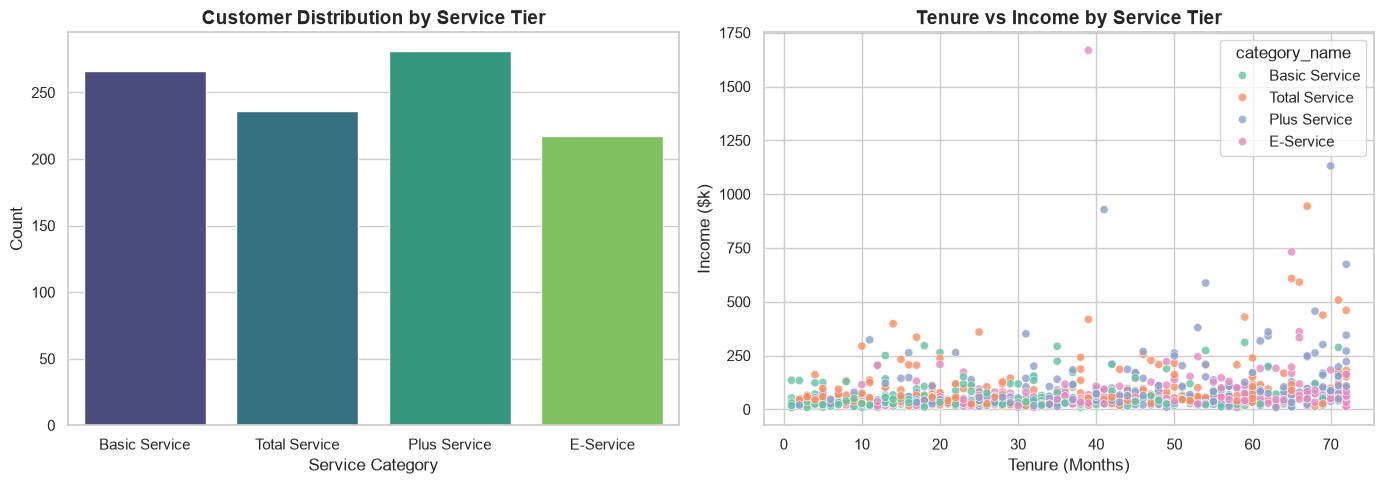

In [3]:
# Cell 3: Visual Analytics (Exploratory Data Analysis)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Category Distribution
sns.countplot(data=df, x='category_name', hue='category_name', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Customer Distribution by Service Tier", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Service Category")
axes[0].set_ylabel("Count")

# Plot 2: Tenure vs Income by Category
sns.scatterplot(data=df, x='tenure', y='income', hue='category_name', palette='Set2', alpha=0.8, ax=axes[1])
axes[1].set_title("Tenure vs Income by Service Tier", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Tenure (Months)")
axes[1].set_ylabel("Income ($k)")

plt.tight_layout()
plt.show()

Model Training Complete!
Random Forest Classification Accuracy: 36.50%

Classification Report:
               precision    recall  f1-score   support

           1       0.42      0.45      0.43        60
           2       0.30      0.28      0.29        39
           3       0.42      0.44      0.43        55
           4       0.27      0.24      0.25        46

    accuracy                           0.36       200
   macro avg       0.35      0.35      0.35       200
weighted avg       0.36      0.36      0.36       200



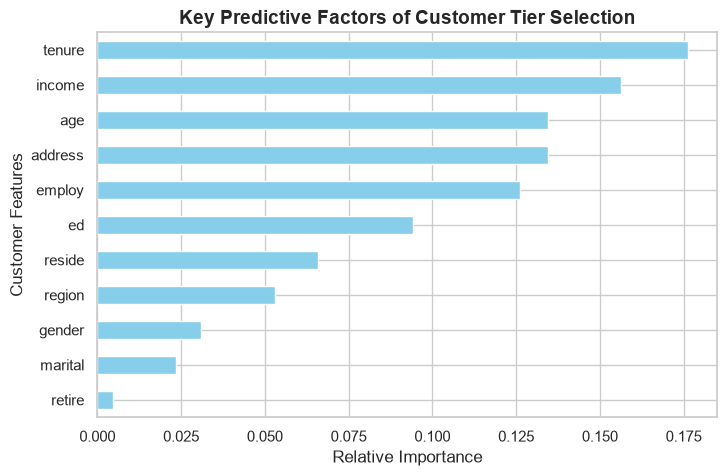

In [4]:
# Cell 4: Machine Learning Model & Feature Importance
X = df.drop(columns=['custcat', 'category_name'])
y = df['custcat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Model Training Complete!")
print(f"Random Forest Classification Accuracy: {acc*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='skyblue')
plt.title("Key Predictive Factors of Customer Tier Selection", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance")
plt.ylabel("Customer Features")
plt.show()